In [58]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import sys
import os

sys.path.append(os.path.abspath(".."))

from pathlib import Path
import sys

In [13]:
from src.data.download import load_config
from src.data.dataset import WindowedTimeSeriesDataset
from src.models.LSTM import BaselineLSTM
from src.evaluation.metrics import compute_regression_metrics, compute_mean_baseline_metrics
from src.visualization.plots import save_loss_curve, save_prediction_plot

from src.training.LSTM_trainer import set_seed, make_dataloader

In [17]:
import os
from pathlib import Path

ROOT_DIR = Path(os.getcwd())
CONFIG_PATH = ROOT_DIR / "config" / "config.yaml"
cfg = load_config("../config/config.yaml")

In [ ]:
splits_dir = ROOT_DIR / cfg["paths"]["splits"]

train_windows_path = splits_dir / cfg["paths"]["train_windows_filename"]
val_windows_path = splits_dir / cfg["paths"]["val_windows_filename"]
test_windows_path = splits_dir / cfg["paths"]["test_windows_filename"]

In [19]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
train_dataset = WindowedTimeSeriesDataset.from_npz("../data/splits/train_windows.npz")
val_dataset = WindowedTimeSeriesDataset.from_npz("../data/splits/val_windows.npz")
test_dataset = WindowedTimeSeriesDataset.from_npz("../data/splits/test_windows.npz")

In [29]:
train_dataset.summary()

Number of samples: 1412
Window size: 30
Number of features: 5
X shape: (1412, 30, 5)
y shape: (1412,)
First target date: 2018-02-19
Last target date: 2021-12-31


In [30]:
train_loader = make_dataloader(train_dataset, batch_size=32, shuffle=True,num_workers=0)
val_loader = make_dataloader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = make_dataloader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [37]:
model = BaselineLSTM(
    n_features=5,
    hidden=64,
    num_layers=1,
    dense=32
).to(device)

In [39]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.00)

In [40]:
best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
train_losses = []
val_losses = []

In [43]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total_samples = 0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device).squeeze(-1)

        optimizer.zero_grad()
        preds = model(X).squeeze(-1)

        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        batch_size = X.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    return running_loss / total_samples

In [44]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    model.eval()
    running_loss = 0.0
    total_samples = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device).squeeze(-1)

        preds = model(X).squeeze(-1)
        loss = criterion(preds, y)

        batch_size = X.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    return running_loss / total_samples

In [45]:
@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    preds_list = []
    targets_list = []

    for X, y in loader:
        X = X.to(device)
        preds = model(X).squeeze(-1).cpu().numpy()
        targets = y.squeeze(-1).cpu().numpy()

        preds_list.append(preds)
        targets_list.append(targets)

    y_pred = np.concatenate(preds_list)
    y_true = np.concatenate(targets_list)
    return y_pred, y_true

In [49]:
for epoch in range(1, 201):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d} | Train loss: {train_loss:.6f} | Val loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= 20:
        print(f"Early stopping en epoch {epoch}. Mejor epoch: {best_epoch} | Best val loss: {best_val_loss:.6f}")
        break

Epoch 001 | Train loss: 0.024481 | Val loss: 1.287078
Epoch 002 | Train loss: 0.024364 | Val loss: 1.360707
Epoch 003 | Train loss: 0.024746 | Val loss: 1.418301
Epoch 004 | Train loss: 0.028314 | Val loss: 1.529446
Epoch 005 | Train loss: 0.027125 | Val loss: 1.506859
Epoch 006 | Train loss: 0.027056 | Val loss: 1.493075
Epoch 007 | Train loss: 0.025587 | Val loss: 1.334803
Epoch 008 | Train loss: 0.023375 | Val loss: 1.360055
Epoch 009 | Train loss: 0.029877 | Val loss: 1.348564
Epoch 010 | Train loss: 0.032030 | Val loss: 1.056216
Epoch 011 | Train loss: 0.034407 | Val loss: 1.251528
Epoch 012 | Train loss: 0.023396 | Val loss: 1.365056
Epoch 013 | Train loss: 0.023612 | Val loss: 1.280788
Epoch 014 | Train loss: 0.021470 | Val loss: 1.358768
Epoch 015 | Train loss: 0.022023 | Val loss: 1.423635
Epoch 016 | Train loss: 0.021947 | Val loss: 1.340624
Epoch 017 | Train loss: 0.023406 | Val loss: 1.209084
Epoch 018 | Train loss: 0.036145 | Val loss: 1.307086
Epoch 019 | Train loss: 0.02

In [50]:
y_test_pred, y_test_true = predict(model, test_loader, device)
test_metrics = compute_regression_metrics(y_test_true, y_test_pred)
mean_baseline_metrics = compute_mean_baseline_metrics(train_dataset.y, y_test_true)

In [51]:
def make_mean_baseline_predictions(train_targets, n_samples):
    train_targets = np.asarray(train_targets).reshape(-1)
    mean_value = float(train_targets.mean())
    return np.full(n_samples, mean_value, dtype=np.float32)


def get_dataset_dates(dataset):
    for attr in ["target_dates", "dates", "y_dates"]:
        if hasattr(dataset, attr):
            return pd.to_datetime(np.asarray(getattr(dataset, attr)))
    return np.arange(len(dataset))


# Predicciones
y_val_pred, y_val_true = predict(model, val_loader, device)
y_test_pred, y_test_true = predict(model, test_loader, device)

# Baseline de media usando solo train
y_val_baseline = make_mean_baseline_predictions(train_dataset.y, len(y_val_true))
y_test_baseline = make_mean_baseline_predictions(train_dataset.y, len(y_test_true))

# Métricas
val_metrics = compute_regression_metrics(y_val_true, y_val_pred)
test_metrics = compute_regression_metrics(y_test_true, y_test_pred)

val_baseline_metrics = compute_regression_metrics(y_val_true, y_val_baseline)
test_baseline_metrics = compute_regression_metrics(y_test_true, y_test_baseline)

print("\nValidation metrics - LSTM")
print(val_metrics)

print("\nValidation metrics - Mean baseline")
print(val_baseline_metrics)

print("\nTest metrics - LSTM")
print(test_metrics)

print("\nTest metrics - Mean baseline")
print(test_baseline_metrics)

# Tabla resumen
results_df = pd.DataFrame([
    {"split": "val", "model": "lstm", **val_metrics},
    {"split": "val", "model": "mean_baseline", **val_baseline_metrics},
    {"split": "test", "model": "lstm", **test_metrics},
    {"split": "test", "model": "mean_baseline", **test_baseline_metrics},
])

print("\nResumen de resultados:")
print(results_df)


Validation metrics - LSTM
{'mse': 1.6229463815689087, 'rmse': 1.273949146270752, 'mae': 0.9922472834587097}

Validation metrics - Mean baseline
{'mse': 0.4202435314655304, 'rmse': 0.6482619047164917, 'mae': 0.5064816474914551}

Test metrics - LSTM
{'mse': 1.2408808469772339, 'rmse': 1.1139483451843262, 'mae': 0.8796941637992859}

Test metrics - Mean baseline
{'mse': 0.46822795271873474, 'rmse': 0.6842718124389648, 'mae': 0.5374261736869812}

Resumen de resultados:
  split          model       mse      rmse       mae
0   val           lstm  1.622946  1.273949  0.992247
1   val  mean_baseline  0.420244  0.648262  0.506482
2  test           lstm  1.240881  1.113948  0.879694
3  test  mean_baseline  0.468228  0.684272  0.537426


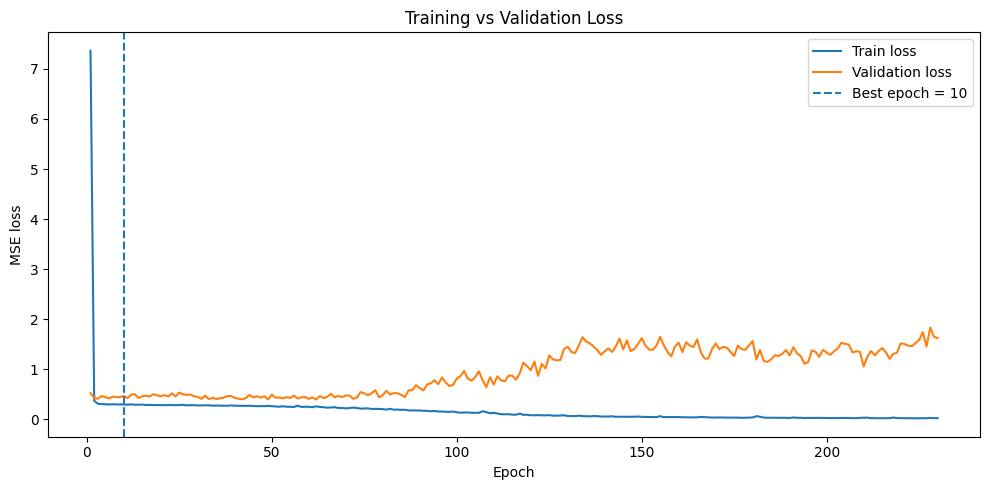

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
def plot_predictions(dates, y_true, y_pred, y_baseline, title, max_points=None):
    dates = np.asarray(dates)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_baseline = np.asarray(y_baseline)

    if max_points is not None and len(y_true) > max_points:
        start = len(y_true) - max_points
        dates = dates[start:]
        y_true = y_true[start:]
        y_pred = y_pred[start:]
        y_baseline = y_baseline[start:]

    plt.figure(figsize=(12, 5))
    plt.plot(dates, y_true, label="True")
    plt.plot(dates, y_pred, label="LSTM prediction")
    plt.plot(dates, y_baseline, label="Mean baseline")
    plt.xlabel("Date")
    plt.ylabel("Target")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_scatter(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([low, high], [low, high], linestyle="--")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_residuals_over_time(dates, y_true, y_pred, title):
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    plt.figure(figsize=(12, 4))
    plt.plot(dates, residuals)
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_residual_histogram(y_true, y_pred, title, bins=30):
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    plt.figure(figsize=(7, 4))
    plt.hist(residuals, bins=bins)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_metric_comparison(model_metrics, baseline_metrics, title):
    metric_names = [m for m in ["rmse", "mae", "r2"] if m in model_metrics and m in baseline_metrics]
    model_values = [model_metrics[m] for m in metric_names]
    baseline_values = [baseline_metrics[m] for m in metric_names]

    x = np.arange(len(metric_names))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, model_values, width, label="LSTM")
    plt.bar(x + width / 2, baseline_values, width, label="Mean baseline")
    plt.xticks(x, metric_names)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_rolling_mae(dates, y_true, y_pred, y_baseline, title, window=30):
    dates = pd.to_datetime(np.asarray(dates))
    model_abs_error = pd.Series(np.abs(np.asarray(y_true) - np.asarray(y_pred)), index=dates)
    baseline_abs_error = pd.Series(np.abs(np.asarray(y_true) - np.asarray(y_baseline)), index=dates)

    model_roll = model_abs_error.rolling(window, min_periods=1).mean()
    baseline_roll = baseline_abs_error.rolling(window, min_periods=1).mean()

    plt.figure(figsize=(12, 4))
    plt.plot(model_roll.index, model_roll.values, label="LSTM rolling MAE")
    plt.plot(baseline_roll.index, baseline_roll.values, label="Baseline rolling MAE")
    plt.xlabel("Date")
    plt.ylabel(f"Rolling MAE ({window})")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

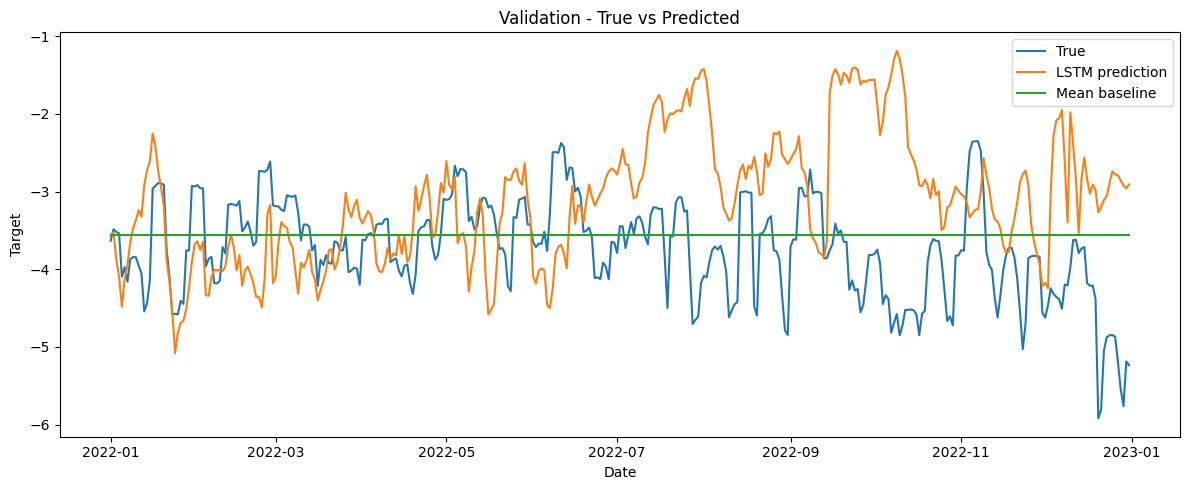

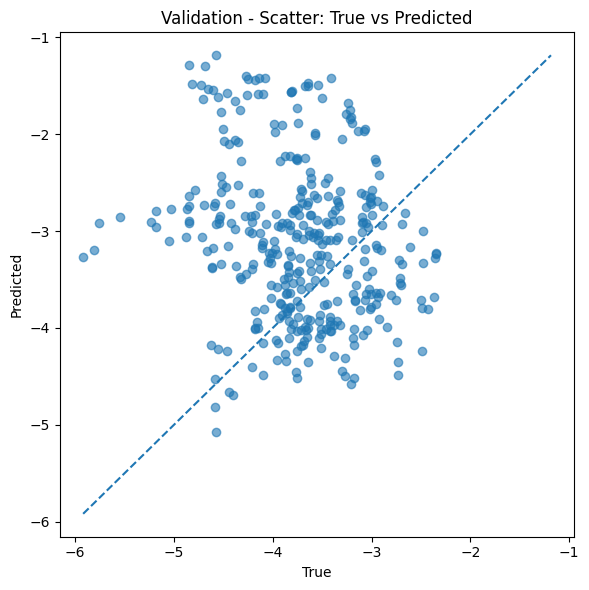

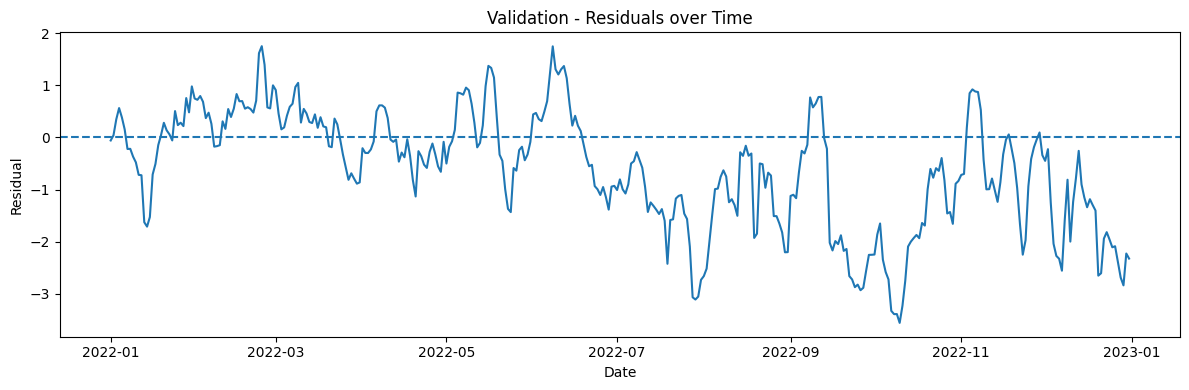

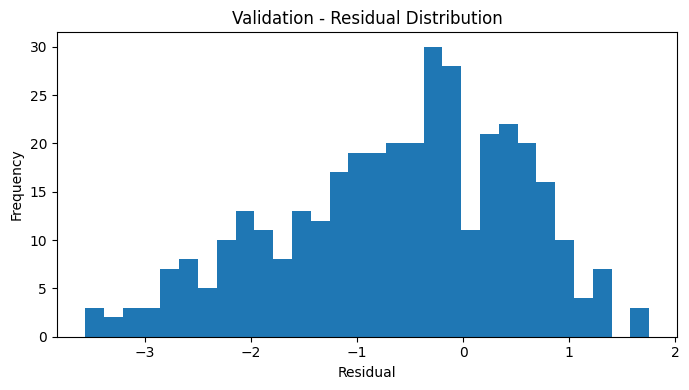

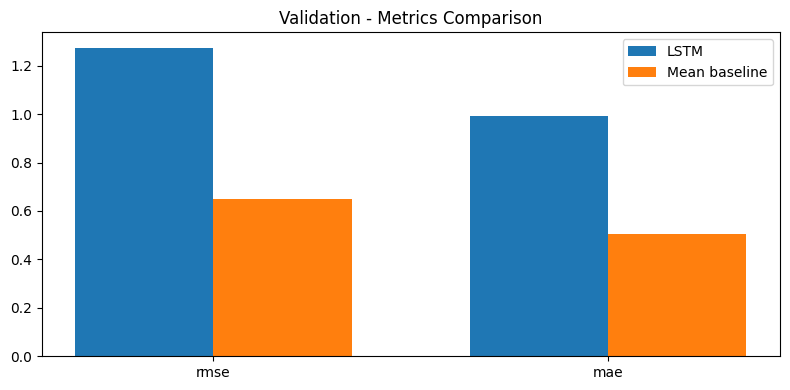

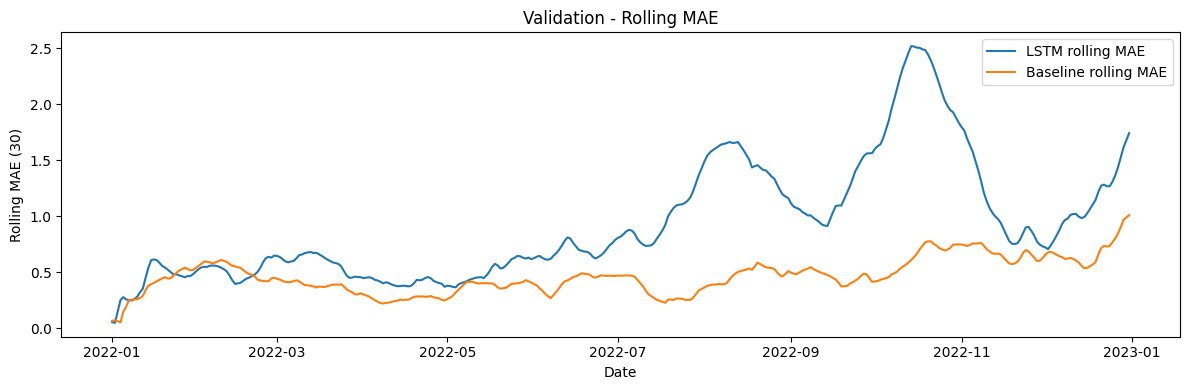

In [56]:
val_dates = get_dataset_dates(val_dataset)

plot_predictions(val_dates, y_val_true, y_val_pred, y_val_baseline, "Validation - True vs Predicted")
plot_scatter(y_val_true, y_val_pred, "Validation - Scatter: True vs Predicted")
plot_residuals_over_time(val_dates, y_val_true, y_val_pred, "Validation - Residuals over Time")
plot_residual_histogram(y_val_true, y_val_pred, "Validation - Residual Distribution")
plot_metric_comparison(val_metrics, val_baseline_metrics, "Validation - Metrics Comparison")
plot_rolling_mae(val_dates, y_val_true, y_val_pred, y_val_baseline, "Validation - Rolling MAE", window=30)

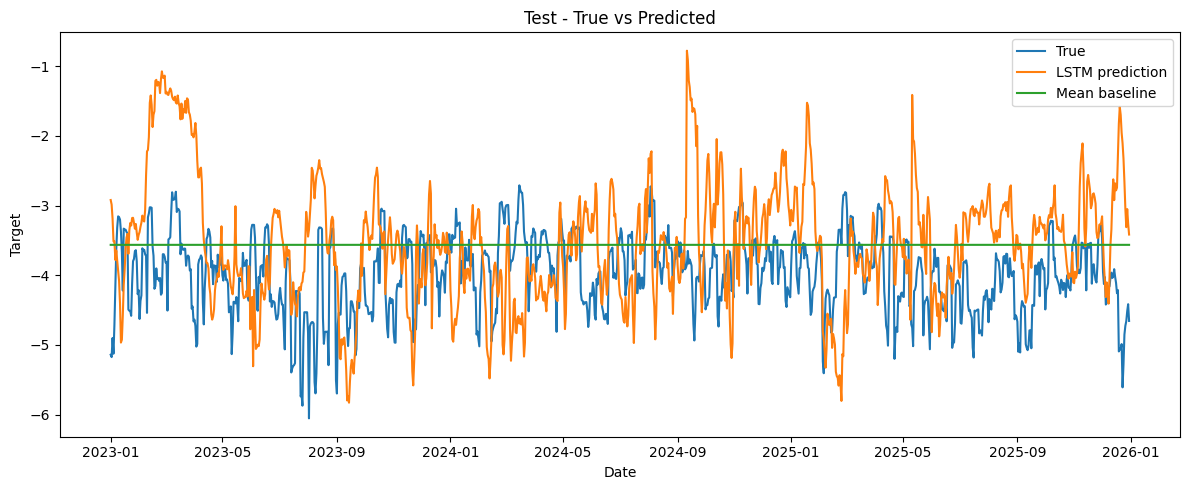

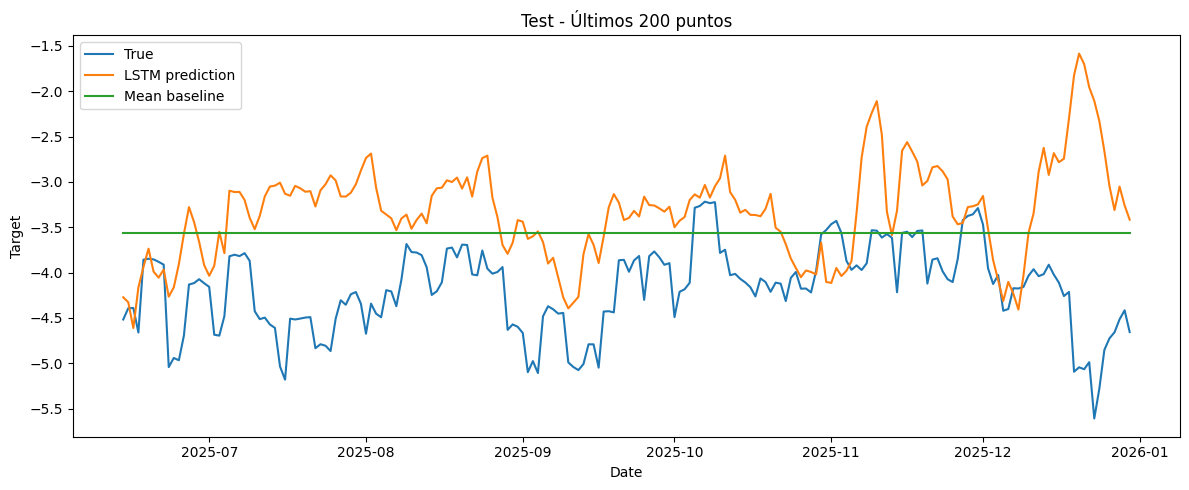

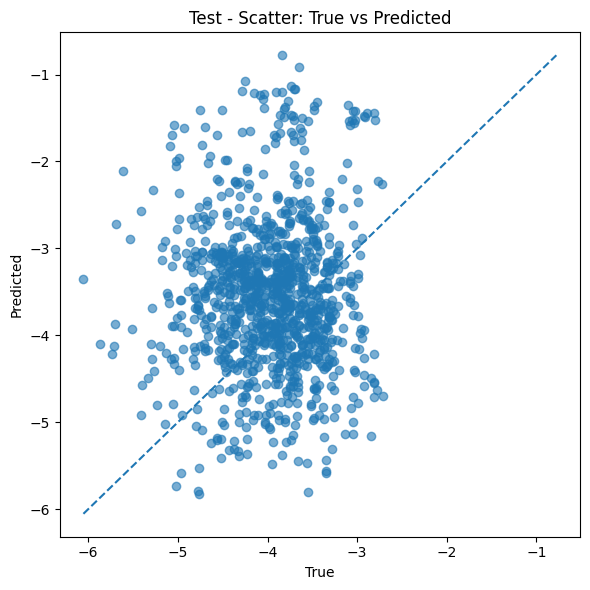

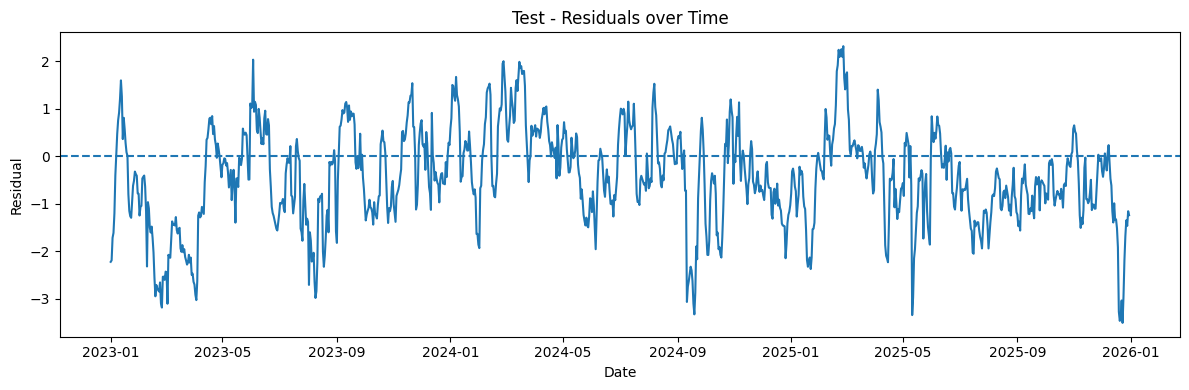

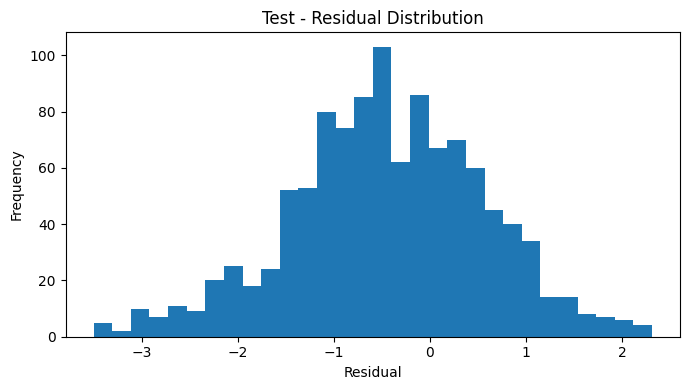

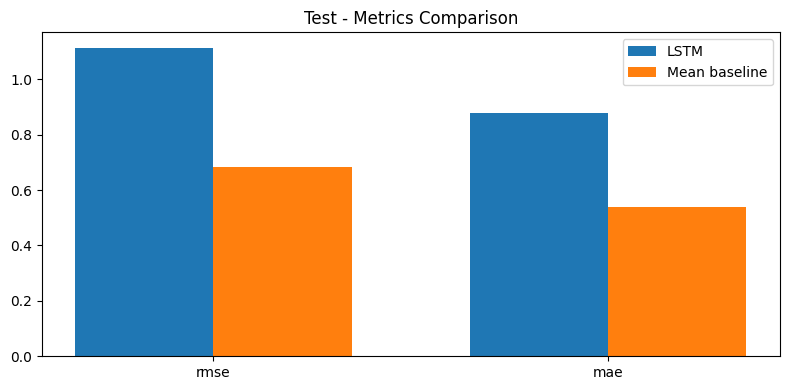

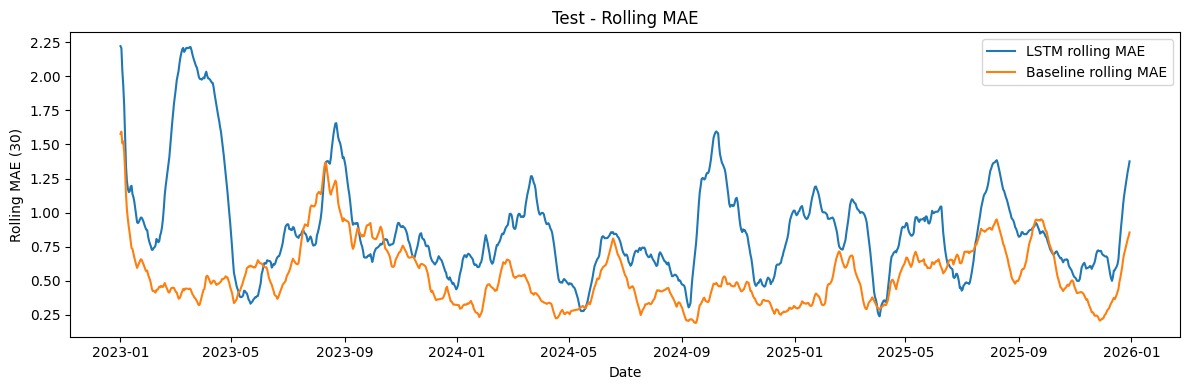

In [57]:
test_dates = get_dataset_dates(test_dataset)

plot_predictions(test_dates, y_test_true, y_test_pred, y_test_baseline, "Test - True vs Predicted")
plot_predictions(test_dates, y_test_true, y_test_pred, y_test_baseline, "Test - Últimos 200 puntos", max_points=200)
plot_scatter(y_test_true, y_test_pred, "Test - Scatter: True vs Predicted")
plot_residuals_over_time(test_dates, y_test_true, y_test_pred, "Test - Residuals over Time")
plot_residual_histogram(y_test_true, y_test_pred, "Test - Residual Distribution")
plot_metric_comparison(test_metrics, test_baseline_metrics, "Test - Metrics Comparison")
plot_rolling_mae(test_dates, y_test_true, y_test_pred, y_test_baseline, "Test - Rolling MAE", window=30)